# CropCatcher — Guide IIIF / IIIF Usage Guide

**FR** — Deux cas d'usage de `Matcher.search_iiif` sur de vrais manifestes Gallica, à partir du jeu d'évaluation (`tests/fixtures/mandragore/`) : **A.** je sais dans quel manifeste chercher ; **B.** je teste plusieurs manifestes pour plusieurs images.

**EN** — Two usage patterns for `Matcher.search_iiif` against real Gallica manifests, using the evaluation dataset (`tests/fixtures/mandragore/`): **A.** I know which manifest to search; **B.** I test several manifests for several images.

> Ce notebook effectue des requêtes vers `gallica.bnf.fr`. / Real network requests to `gallica.bnf.fr`.

## 0. Setup

**FR** — Imports et chargement de `dataset.json` : pour chaque cas, le crop local, le manifeste IIIF et le service Image API de sa vraie page source.

**EN** — Imports and loading of `dataset.json`: per case, the local crop, the IIIF manifest and the Image API service of its true source page.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

from cropcatcher import Matcher
from cropcatcher.visualization import draw_localization, draw_matches

%matplotlib inline


def show(image, title="", ax=None):
    """Display a grayscale or BGR OpenCV image with matplotlib."""
    owns_fig = ax is None
    if owns_fig:
        _, ax = plt.subplots(figsize=(5, 5))
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
    if owns_fig:
        plt.show()


DATASET_DIR = Path("../tests/fixtures/mandragore")
dataset = json.loads((DATASET_DIR / "dataset.json").read_text())
cases = {c["id"]: c for c in dataset["cases"]}
print(f"{len(cases)} cases available:", ", ".join(cases))


10 cases available: gaston_phebus_f2v_veneurs, gaston_phebus_f5v_cerf, barlaam_f1v_saints, barlaam_f11v_josaphat, cynegetica_f4v_chasse, cynegetica_f9_chevaux, petrarque_f1_roue, petrarque_f8_raison, latin757_f24_creation, latin757_f4_armes


## A. Un manifeste connu / A known manifest

**FR** — J'ai un crop et je connais son manuscrit : je cherche la bonne page dans ce seul manifeste. C'est l'appel le plus direct. Le manifeste entier est parcouru ici ; sur un manuscrit volumineux, `max_canvases` borne le nombre de pages examinées, au risque d'exclure la cible si elle est au-delà de la coupe.

**EN** — I have a crop and know its manuscript: I look for the right page in that single manifest. This is the most direct call. The whole manifest is scanned here; on a large manuscript, `max_canvases` caps how many pages are examined, at the risk of excluding the target if it lies beyond the cut.

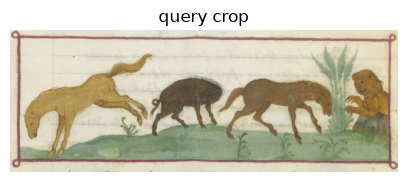

MatchResult(source='https://gallica.bnf.fr/iiif/ark:/12148/btv1b60005116/f23', score=0.947, matches=385, inliers=351, inlier_ratio=0.912, bbox=(111, 170, 599, 348))
MatchResult(source='https://gallica.bnf.fr/iiif/ark:/12148/btv1b60005116/f83', score=0.839, matches=127, inliers=93, inlier_ratio=0.732, bbox=(529, 214, 529, 214))
MatchResult(source='https://gallica.bnf.fr/iiif/ark:/12148/btv1b60005116/f52', score=0.815, matches=136, inliers=94, inlier_ratio=0.691, bbox=(327, 640, 327, 640))

found the true source: True


In [2]:
case = cases["cynegetica_f9_chevaux"]
query_path = DATASET_DIR / case["crop_path"]
show(cv2.imread(str(query_path)), "query crop")

matcher = Matcher(method="sift")
results = matcher.search_iiif(
    query=query_path,
    manifests=case["manifest_url"],
    max_workers=8
)

for result in results.top(3):
    print(result)
print("\nfound the true source:", results.best.source == case["service_id"])


**FR** — `results.best` donne la page gagnante. `explain_iiif` la retélécharge pour visualiser les appariements et la localisation.

**EN** — `results.best` gives the winning page. `explain_iiif` re-downloads it to visualize the matches and the localization.

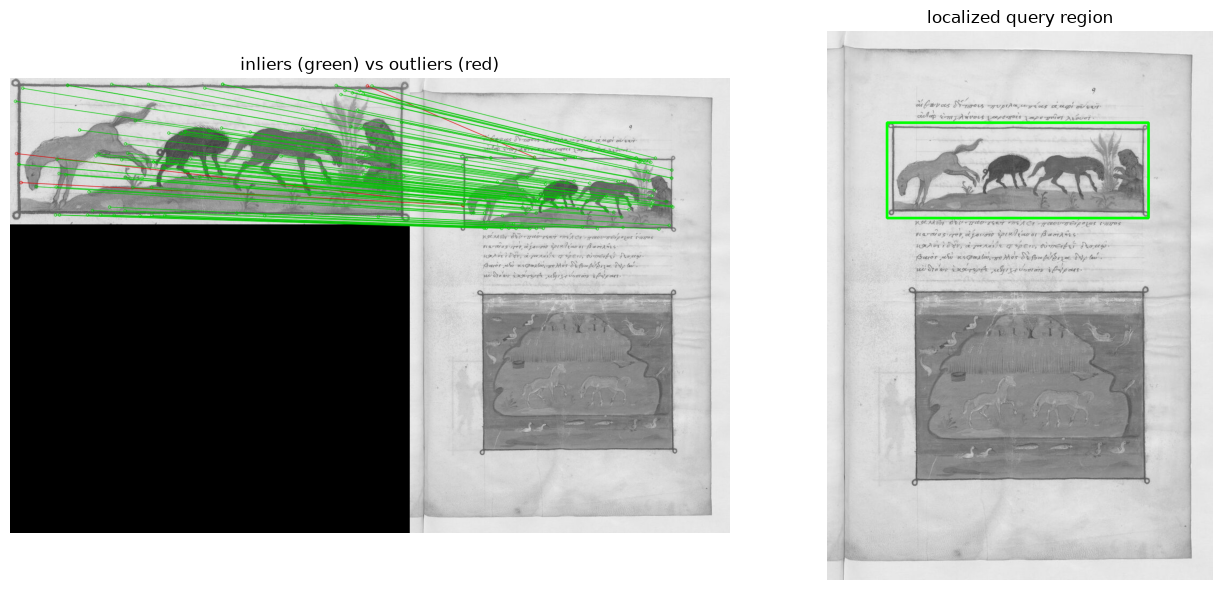

In [3]:
debug = matcher.explain_iiif(query=query_path, service_id=results.best.source)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
show(draw_matches(debug), "inliers (green) vs outliers (red)", axes[0])
show(
    draw_localization(debug.candidate_image, debug.query_image.shape, debug.result.homography),
    "localized query region",
    axes[1],
)
plt.tight_layout()
plt.show()


## B. Plusieurs manifestes, plusieurs images / Several manifests, several images

**FR** — J'ai plusieurs crops et une liste restreinte de manifestes candidats : pour chaque image, je veux savoir dans lequel elle se trouve et à quelle page. `search_iiif` accepte directement une liste de manifestes.

**FR** — Ci-dessous, deux crops issus de manuscrits différents sont cherchés dans la même liste : chacun doit retrouver son manifeste et sa page malgré les pages de l'autre manuscrit en distracteurs.

**EN** — I have several crops and a short list of candidate manifests: for each image, I want to know which one it is in, and on what page. `search_iiif` accepts a list of manifests directly.

**EN** — Below, two crops from different manuscripts are searched against the same list: each should find its own manifest and page despite the other manuscript's pages acting as distractors.

In [4]:
query_ids = ["gaston_phebus_f2v_veneurs", "cynegetica_f4v_chasse"]
manifests_to_test = [cases[qid]["manifest_url"] for qid in query_ids]

for qid in query_ids:
    case = cases[qid]
    query_path = DATASET_DIR / case["crop_path"]

    results = matcher.search_iiif(
        query=query_path,
        manifests=manifests_to_test,
    )

    best = results.best
    correct = best.source == case["service_id"]
    print(f"{qid}:")
    print(f"  best match  -> {best.source}  (score={best.score:.2f})")
    print(f"  true source -> {case['service_id']}")
    print(f"  correctly identified: {correct}\n")


gaston_phebus_f2v_veneurs:
  best match  -> https://gallica.bnf.fr/iiif/ark:/12148/btv1b525064305/f14  (score=0.98)
  true source -> https://gallica.bnf.fr/iiif/ark:/12148/btv1b525064305/f14
  correctly identified: True

cynegetica_f4v_chasse:
  best match  -> https://gallica.bnf.fr/iiif/ark:/12148/btv1b60005116/f12  (score=0.98)
  true source -> https://gallica.bnf.fr/iiif/ark:/12148/btv1b60005116/f12
  correctly identified: True



## Pour aller plus loin / Going further

**FR** —
- `max_canvases`, `size` et `max_workers` contrôlent le coût réseau d'une recherche.
- Pour plusieurs requêtes sur le même corpus, préférez `Index` : `add_iiif(...)` une fois, puis `search(...)` par image.
- Le jeu complet (`Segments_Enluminures.csv`, 631 enluminures, 8 manuscrits) est dans `tests/fixtures/mandragore/`.

**EN** —
- `max_canvases`, `size` and `max_workers` control a search's network cost.
- For several queries over the same corpus, prefer `Index`: `add_iiif(...)` once, then `search(...)` per image.
- The full dataset (`Segments_Enluminures.csv`, 631 illuminations, 8 manuscripts) lives in `tests/fixtures/mandragore/`.